In [7]:
from datasets import load_dataset

ds = load_dataset("AlexOrtzx/go_emotions_max_500")

In [8]:
from datasets import load_dataset
import pandas as pd

# Combine all splits into a single dataset
train_df = ds["train"].to_pandas()
val_df = ds["validation"].to_pandas()
test_df = ds["test"].to_pandas()
complete_dataset = pd.concat([train_df, val_df, test_df], ignore_index=True)

# Save the dataset as a CSV file
complete_dataset.to_csv("go_emotions_complete.csv", index=False , sep=',')
print("Dataset saved as go_emotions_complete.csv")

complete_dataset

Dataset saved as go_emotions_complete.csv


,input,output,id
0,"You should see the absurd number of ""gays for ...",[admiration],eey2egt
1,So no. All you have is lies and delusions. Tha...,[gratitude],ef0jlbi
2,This look is fab you can't call everything cri...,[admiration],edgu3rw
3,[NAME] ruled out due to injury. [NAME] starts....,[neutral],edw8ngq
4,"That’s fair, personally the manufactured elect...","[admiration, approval]",eegi2ey
...,...,...,...
54257,It does mean they are parroting it when they s...,[neutral],edi4p1h
54258,"If my mom were still alive, she'd be so pissed...",[realization],edztfzy
54259,"Thank you, I hope you do too. You can always m...","[gratitude, optimism]",eebot5y
54260,Starting super simple helps; compliment strang...,[approval],eczpr3k


In [9]:
import pandas as pd
import re

# Function to remove non-letter characters and emojis
def clean_text(text):
    if isinstance(text, str):  # Check if the input is a string
        # Remove emojis using regex
        text = re.sub(r'[^\w\s,]', '', text, flags=re.UNICODE)  # Remove emojis
        # Remove any characters that are not letters or spaces
        text = re.sub(r'[^a-zA-Z\s]', '', text)
    return text

# Load the dataset
df = pd.read_csv("go_emotions_complete.csv")

# Sample 1000 rows
df = df.sample(n=1000, random_state=42)  # Ensures reproducibility
if "id" in df.columns:
    df = df.drop(columns=["id"])

# Remove square brackets and single quotes from the 'output' column
df['output'] = df['output'].str.strip('[]').str.replace("'", "", regex=True)

# Convert both 'output' and 'input' to lowercase
df['output'] = df['output'].str.lower()
df['input'] = df['input'].str.lower()

# Clean 'input' column by removing non-letter characters and emojis
df['input'] = df['input'].apply(clean_text)

# Save the modified sample to a new CSV file
df.to_csv("go_emotions_complete.csv", index=False)

# Display the first few rows of the modified sample dataset
df.head()


,input,output
21717,praise name hope his health issues have gotten...,approval optimism pride
28493,aww thank you thats very sweet,gratitude
47416,dont care have fun got better things to do,amusement caring
45071,yeah i just visited there and it seems more di...,approval
33019,heres hoping,optimism


In [10]:
# Define the mapping of original emotions to generalized categories
emotion_mapping = {
    "admiration": "happy",
    "amusement": "happy",
    "anger": "sad",
    "annoyance": "sad",
    "approval": "happy",
    "caring": "happy",
    "confusion": "neutral",
    "curiosity": "neutral",
    "desire": "neutral",
    "disappointment": "sad",
    "disapproval": "sad",
    "disgust": "sad",
    "embarrassment": "sad",
    "excitement": "happy",
    "fear": "sad",
    "gratitude": "happy",
    "grief": "sad",
    "joy": "happy",
    "love": "happy",
    "nervousness": "sad",
    "optimism": "happy",
    "pride": "happy",
    "realization": "neutral",
    "relief": "happy",
    "remorse": "sad",
    "sadness": "sad",
    "surprise": "neutral",
    "neutral": "neutral"
}

# Generalize emotions
def generalize_emotions(output):
    try:
        # Remove square brackets and quotes from the string
        output = output.strip("[]").replace("'", "").lower()
        
        # Split the emotions if necessary
        emotions = output.split(',') if ',' in output else output.split()  # Handle comma or space separation
        
        # Generalize emotions by mapping each one
        generalized = [emotion_mapping.get(emotion.strip(), "neutral") for emotion in emotions]  # Default to "neutral" if mapping is missing
        
        # Return the first generalized emotion
        return generalized[0]
    except Exception as e:
        print(f"Error for output: {output} - {e}")
        return "neutral"  # Default to neutral if an error occurs

# Apply the function to the 'output' column
df['output'] = df['output'].apply(generalize_emotions)

# Overwrite the same CSV file with updated data
df.to_csv("go_emotions_complete.csv", index=False)

# Display the first few rows
print(df.head())


                                                   input output
21717  praise name hope his health issues have gotten...  happy
28493                     aww thank you thats very sweet  happy
47416         dont care have fun got better things to do  happy
45071  yeah i just visited there and it seems more di...  happy
33019                                       heres hoping  happy


In [11]:
from transformers import BertTokenizer
import torch

# Initialize the tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def preprocess_csv_data(file_path, max_length=128):
    """
    Preprocesses a CSV dataset for input into a BERT-based model.

    Args:
    - file_path (str): Path to the CSV file containing 'input' and 'output' columns.
    - max_length (int): Maximum token length for padding/truncation.

    Returns:
    - input_ids (torch.Tensor): Tensor of token IDs.
    - attention_mask (torch.Tensor): Tensor of attention masks.
    - labels (list): List of emotion labels.
    """
    # Load the dataset
    dataset = pd.read_csv(file_path)

    # Extract the text and labels
    texts = dataset["input"].astype(str).tolist()
    labels = dataset["output"].astype(str).tolist()

    # Tokenize and encode texts
    encoded = tokenizer(
        texts,
        max_length=max_length,
        padding="max_length",  # Pad to the max_length
        truncation=True,  # Truncate longer texts
        return_tensors="pt"  # Return PyTorch tensors
    )

    return encoded["input_ids"], encoded["attention_mask"], labels

# Example usage
csv_file_path = "go_emotions_complete.csv"

input_ids, attention_mask, labels = preprocess_csv_data(csv_file_path)

# Display sample outputs
print("Sample Input IDs:", input_ids[:2])
print("Sample Attention Masks:", attention_mask[:2])
print("Sample Labels:", labels[:2])


Sample Input IDs: tensor([[  101,  8489,  2171,  3246,  2010,  2740,  3314,  2031,  5407,  2488,
         12043,  2323,  2022,  2006,  1037, 20127,  2157,  2085,   102,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     0,     0,     0,     0,     0,     0,     0,
             0,     0,     0,     

In [12]:
from sklearn.preprocessing import MultiLabelBinarizer

# One-hot encode labels
mlb = MultiLabelBinarizer()
one_hot_labels = mlb.fit_transform([[label] for label in labels])  # Wrap each label in a list

# Save the label mapping for later use
label_mapping = dict(zip(mlb.classes_, range(len(mlb.classes_))))
print("Label Mapping:", label_mapping)


Label Mapping: {'happy': 0, 'neutral': 1, 'sad': 2}


In [13]:
from sklearn.model_selection import train_test_split
import torch

# First split: 80% training, 20% temporary (for validation and test)
train_inputs, temp_inputs, train_labels, temp_labels = train_test_split(
    input_ids, one_hot_labels, test_size=0.2, random_state=42
)
train_masks, temp_masks, _, _ = train_test_split(
    attention_mask, one_hot_labels, test_size=0.2, random_state=42
)

# Second split: 50% of the temporary data goes to validation and 50% to test
val_inputs, test_inputs, val_labels, test_labels = train_test_split(
    temp_inputs, temp_labels, test_size=0.5, random_state=42
)
val_masks, test_masks, _, _ = train_test_split(
    temp_masks, temp_labels, test_size=0.5, random_state=42
)

# Convert data to PyTorch tensors
train_inputs = torch.tensor(train_inputs)
val_inputs = torch.tensor(val_inputs)
test_inputs = torch.tensor(test_inputs)

train_masks = torch.tensor(train_masks)
val_masks = torch.tensor(val_masks)
test_masks = torch.tensor(test_masks)

train_labels = torch.tensor(train_labels)
val_labels = torch.tensor(val_labels)
test_labels = torch.tensor(test_labels)


/var/folders/f2/r5kntlr91r91717ccct0b_840000gn/T/ipykernel_73483/4108280512.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_inputs = torch.tensor(train_inputs)
/var/folders/f2/r5kntlr91r91717ccct0b_840000gn/T/ipykernel_73483/4108280512.py:22: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_inputs = torch.tensor(val_inputs)
/var/folders/f2/r5kntlr91r91717ccct0b_840000gn/T/ipykernel_73483/4108280512.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_inputs = torch.tensor(test_inputs)
/var/folders/f2/r5kntlr91r91717ccct0b

In [14]:
from torch.utils.data import DataLoader, TensorDataset
import torch

# Assuming input_ids, attention_mask, and encoded_labels are ready and have been split
train_data = TensorDataset(train_inputs, train_masks, train_labels)
val_data = TensorDataset(val_inputs, val_masks, val_labels)
test_data = TensorDataset(test_inputs, test_masks, test_labels)  # Add the test dataset

# Define batch size
batch_size = 32

# Create DataLoaders for train, validation, and test sets
train_dataloader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)  



In [15]:
from transformers import BertTokenizer, BertModel
import torch
import torch.nn as nn

class TextEmotionModel(nn.Module):
    def __init__(self, num_classes):
        super(TextEmotionModel, self).__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(self.bert.config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_output = outputs.last_hidden_state[:, 0, :]  # CLS token embedding
        x = self.dropout(cls_output)
        return self.fc(x)

# Initialize the tokenizer for preprocessing
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")


In [16]:
# Define the number of emotion classes based on your dataset
num_classes = len(label_mapping)  # Replace `label_mapping` with the actual mapping

# Create an instance of the model
model = TextEmotionModel(num_classes=num_classes)

# Move the model to the appropriate device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


TextEmotionModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementw

In [17]:
from transformers import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

optimizer = AdamW(model.parameters(), lr=5e-5, eps=1e-4)  # Learning rate and epsilon
criterion = nn.CrossEntropyLoss()  # For single-label classification

/opt/anaconda3/lib/python3.11/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(


In [ ]:
import torch
import matplotlib.pyplot as plt

# Initialize lists to store losses for each epoch
train_losses = []
val_losses = []

epochs = 3
for epoch in range(epochs):
    print(f"Epoch {epoch + 1}/{epochs}")

    # Training phase
    model.train()  # Set the model to training mode
    total_train_loss = 0
    for step, batch in enumerate(train_dataloader):
        b_input_ids, b_input_mask, b_labels = [x.to(device) for x in batch]

        # Convert one-hot labels to class indices (if applicable)
        if b_labels.ndim > 1:  # Correct usage of ndim to check if b_labels are one-hot encoded
            b_labels = torch.argmax(b_labels, dim=1)

        # Ensure b_labels are of type long (int64) for CrossEntropyLoss
        b_labels = b_labels.long()

        # Zero gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(input_ids=b_input_ids, attention_mask=b_input_mask)

        # Calculate loss
        loss = criterion(outputs, b_labels)

        # Backward pass and optimization
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_dataloader)
    train_losses.append(avg_train_loss)  # Append the average training loss for the epoch
    print(f"Training Loss: {avg_train_loss}")

    # Validation phase
    model.eval()  # Set the model to evaluation mode
    total_val_loss = 0
    for batch in val_dataloader:
        b_input_ids, b_input_mask, b_labels = [x.to(device) for x in batch]

        # Convert one-hot labels to class indices (if applicable)
        if b_labels.ndim > 1:  # Correct usage of ndim
            b_labels = torch.argmax(b_labels, dim=1)

        # Ensure b_labels are of type long (int64) for CrossEntropyLoss
        b_labels = b_labels.long()

        with torch.no_grad():
            # Forward pass
            outputs = model(input_ids=b_input_ids, attention_mask=b_input_mask)

            # Calculate loss
            loss = criterion(outputs, b_labels)
            total_val_loss += loss.item()

    if len(val_dataloader) > 0:  # Avoid division by zero
        avg_val_loss = total_val_loss / len(val_dataloader)
    else:
        avg_val_loss = float("inf")  # Placeholder if val_dataloader is empty

    val_losses.append(avg_val_loss)  # Append the average validation loss for the epoch
    print(f"Validation Loss: {avg_val_loss}")

Epoch 1/3
Training Loss: 1.0524958443641663
Validation Loss: 0.8703695237636566
Epoch 2/3


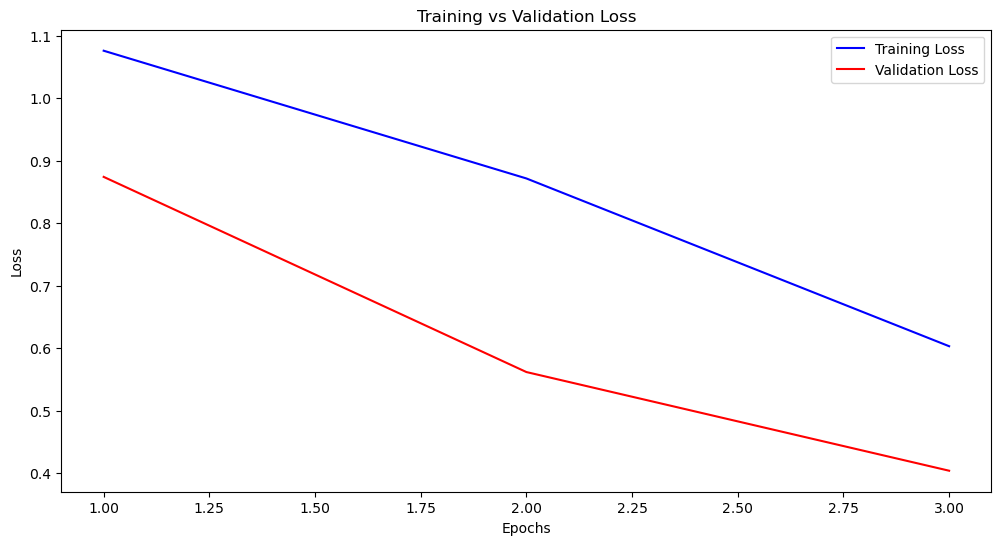

In [ ]:
# Plot Training vs Validation Loss
epochs_range = range(1, len(train_losses) + 1)

plt.figure(figsize=(12, 6))
plt.plot(epochs_range, train_losses, label="Training Loss", color="blue")
plt.plot(epochs_range, val_losses, label="Validation Loss", color="red")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

In [ ]:
torch.save(model.state_dict(), "text_emotion_model.pth")
print("Model saved as text_emotion_model.pth")


Model saved as text_emotion_model.pth


In [ ]:
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Label mapping
label_mapping = {'happy': 0, 'neutral': 1, 'sad': 2}
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

def evaluate_test(model, test_dataloader, criterion, device):
    model.eval()  # Set the model to evaluation mode
    total_test_loss = 0
    all_test_labels = []
    all_test_predictions = []

    for batch in test_dataloader:
        b_input_ids, b_input_mask, b_labels = [x.to(device) for x in batch]

        # Convert one-hot labels to class indices (if applicable)
        if b_labels.ndim > 1:  # Check if b_labels are one-hot encoded
            b_labels = torch.argmax(b_labels, dim=1)
        b_labels = b_labels.long()

        with torch.no_grad():
            # Forward pass
            outputs = model(input_ids=b_input_ids, attention_mask=b_input_mask)

            # Calculate loss
            loss = criterion(outputs, b_labels)
            total_test_loss += loss.item()

            # Track predictions and labels
            _, predicted = torch.max(outputs, 1)
            all_test_predictions.extend(predicted.cpu().numpy())
            all_test_labels.extend(b_labels.cpu().numpy())

    # Calculate overall metrics
    avg_test_loss = total_test_loss / len(test_dataloader)
    test_accuracy = accuracy_score(all_test_labels, all_test_predictions)

    print(f"Test Loss: {avg_test_loss:.4f}")
    print(f"Test Accuracy: {test_accuracy:.4f}")

    # Classification report
    print("\nClassification Report:")
    print(classification_report(all_test_labels, all_test_predictions, target_names=label_mapping.keys()))

    # Confusion matrix
    print("\nConfusion Matrix:")
    cm = confusion_matrix(all_test_labels, all_test_predictions)
    print(cm)

    return avg_test_loss, test_accuracy, cm

# Example usage
# Ensure your test_dataloader is prepared with the same preprocessing as training and validation
test_loss, test_accuracy, confusion_matrix = evaluate_test(model, test_dataloader, criterion, device)


Test Loss: 0.6732
Test Accuracy: 0.7500

Classification Report:
              precision    recall  f1-score   support

       happy       0.75      0.84      0.79        32
     neutral       0.84      0.71      0.77        51
         sad       0.57      0.71      0.63        17

    accuracy                           0.75       100
   macro avg       0.72      0.75      0.73       100
weighted avg       0.76      0.75      0.75       100


Confusion Matrix:
[[27  4  1]
 [ 7 36  8]
 [ 2  3 12]]
